# PHÂN TÍCH VÀ DỰ ĐOÁN GIÁ XĂNG TẠI VIỆT NAM (2020–2026)
### Theo kỳ điều hành — Dữ liệu: Petrolimex / CafeF

**Sinh viên:** Nguyễn Tiến Đức — MSSV: K225480106081
**Môn học:** Khoa học Dữ liệu

---
**Mục tiêu:** Phân tích biến động giá xăng E5 RON92 & RON95 tại Việt Nam giai đoạn 2020–2026,
trả lời 5 câu hỏi phân tích và 2 câu hỏi dự đoán/phân lớp.

**Lưu ý về dữ liệu:** Dữ liệu gồm các mốc giá tiêu biểu (không phải TẤT CẢ các kỳ điều hành)
được gắn với các sự kiện kinh tế/dịch bệnh quan trọng trong giai đoạn 2020–2026. Điều này phù hợp
để phân tích xu hướng và các giai đoạn đặc trưng, nhưng có thể không phản ánh chính xác 100% tần suất
điều hành thực tế (thường là 7–10 ngày/lần theo quy định hiện hành).


## 1. Import thư viện và đọc dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, silhouette_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("xangdau_2020_2025.csv", parse_dates=["Ngay"])
df = df.sort_values("Ngay").reset_index(drop=True)
df.head(10)


,Ngay,RON95,E5RON92,DauDiesel,Su_kien
0,2020-01-13,18880,18050,15510,Gia truoc dich COVID
1,2020-03-17,16390,15680,13700,COVID bat dau bung phat
2,2020-04-17,13310,12710,11100,Dau the gioi am lich su
3,2020-05-11,15000,14350,12830,Dau hoi phuc nhe
4,2020-06-26,15000,14350,12530,On dinh
5,2020-08-24,16990,16230,14360,Binh thuong moi
6,2020-10-26,16240,15510,13810,Dich tro lai
7,2020-12-14,17050,16280,14500,Cuoi nam 2020
8,2021-01-25,17600,16820,14970,Dau nam 2021
9,2021-03-22,18580,17760,15440,Vac-xin trien khai


## 2. Tiền xử lý dữ liệu (Data Wrangling)

Tạo các cột dẫn xuất cần thiết cho phân tích:
- `Khoang_cach_ngay`: số ngày giữa 2 mốc giá liên tiếp (đại diện cho **tần suất** điều chỉnh)
- `ThayDoi_*`, `PhanTram_*`: mức thay đổi tuyệt đối & tương đối (đại diện cho **biên độ**)
- `Huong_RON95`: hướng thay đổi (Tăng / Giảm / Giữ nguyên)


In [2]:
df["Khoang_cach_ngay"] = df["Ngay"].diff().dt.days
df["ThayDoi_RON95"]   = df["RON95"].diff()
df["PhanTram_RON95"]  = df["RON95"].pct_change() * 100
df["ThayDoi_E5"]      = df["E5RON92"].diff()
df["PhanTram_E5"]     = df["E5RON92"].pct_change() * 100
df["Nam"]             = df["Ngay"].dt.year
df["Thang"]           = df["Ngay"].dt.month

def huong(x):
    if pd.isna(x):
        return np.nan
    if x > 0.01:
        return "Tang"
    elif x < -0.01:
        return "Giam"
    return "Giu nguyen"

df["Huong_RON95"] = df["ThayDoi_RON95"].apply(huong)
df["Huong_E5"]     = df["ThayDoi_E5"].apply(huong)

df[["Ngay", "RON95", "E5RON92", "Khoang_cach_ngay",
    "PhanTram_RON95", "Huong_RON95", "Su_kien"]].head(10)


,Ngay,RON95,E5RON92,Khoang_cach_ngay,PhanTram_RON95,Huong_RON95,Su_kien
0,2020-01-13,18880,18050,NaN,NaN,NaN,Gia truoc dich COVID
1,2020-03-17,16390,15680,64.0,-13.188559,Giam,COVID bat dau bung phat
2,2020-04-17,13310,12710,31.0,-18.791946,Giam,Dau the gioi am lich su
3,2020-05-11,15000,14350,24.0,12.697220,Tang,Dau hoi phuc nhe
4,2020-06-26,15000,14350,46.0,0.000000,Giu nguyen,On dinh
5,2020-08-24,16990,16230,59.0,13.266667,Tang,Binh thuong moi
6,2020-10-26,16240,15510,63.0,-4.414361,Giam,Dich tro lai
7,2020-12-14,17050,16280,49.0,4.987685,Tang,Cuoi nam 2020
8,2021-01-25,17600,16820,42.0,3.225806,Tang,Dau nam 2021
9,2021-03-22,18580,17760,56.0,5.568182,Tang,Vac-xin trien khai


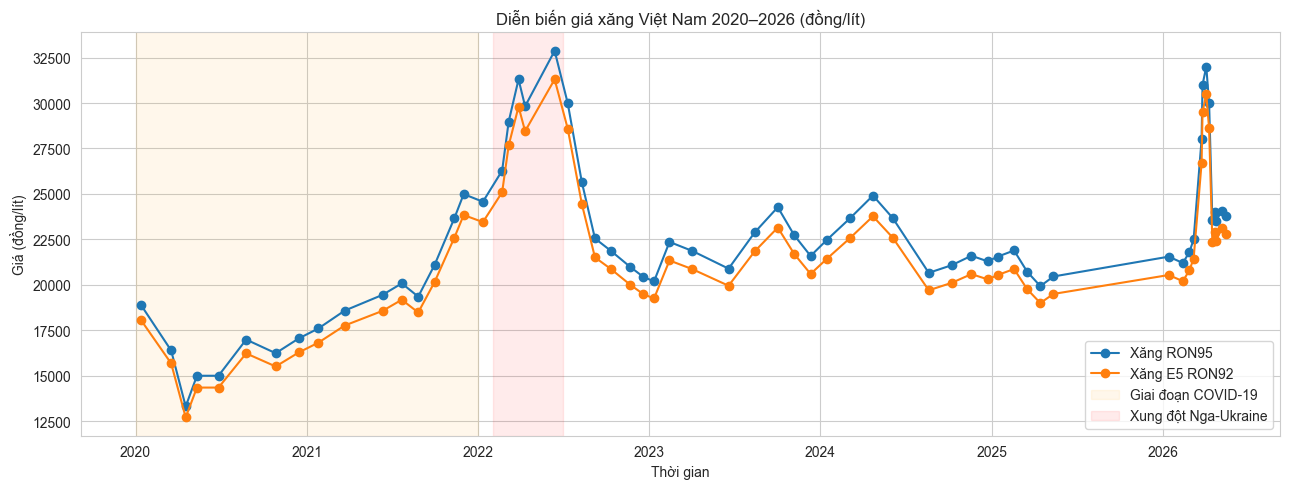

In [3]:
# Trực quan hóa tổng quan: diễn biến giá theo thời gian
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df["Ngay"], df["RON95"], marker="o", label="Xăng RON95", linewidth=1.5)
ax.plot(df["Ngay"], df["E5RON92"], marker="o", label="Xăng E5 RON92", linewidth=1.5)
ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2021-12-31"),
           color="orange", alpha=0.08, label="Giai đoạn COVID-19")
ax.axvspan(pd.Timestamp("2022-02-01"), pd.Timestamp("2022-07-01"),
           color="red", alpha=0.08, label="Xung đột Nga-Ukraine")
ax.set_title("Diễn biến giá xăng Việt Nam 2020–2026 (đồng/lít)")
ax.set_xlabel("Thời gian")
ax.set_ylabel("Giá (đồng/lít)")
ax.legend()
plt.tight_layout()
plt.show()


## 3. Câu hỏi phân tích 1: Tần suất và biên độ điều chỉnh giá xăng (2020–2026)

**Tần suất** = khoảng thời gian giữa các lần điều chỉnh.
**Biên độ** = mức thay đổi (%) mỗi lần điều chỉnh.


In [4]:
print("=== TẦN SUẤT (khoảng cách ngày giữa các mốc) ===")
print(df["Khoang_cach_ngay"].describe().round(1))

print("\n=== BIÊN ĐỘ (% thay đổi RON95 mỗi lần) ===")
print(df["PhanTram_RON95"].describe().round(2))

print("\n=== Số lần Tăng / Giảm / Giữ nguyên (RON95) ===")
print(df["Huong_RON95"].value_counts())


=== TẦN SUẤT (khoảng cách ngày giữa các mốc) ===
count     61.0
mean      37.9
std       33.0
min        2.0
25%       21.0
50%       35.0
75%       49.0
max      246.0
Name: Khoang_cach_ngay, dtype: float64

=== BIÊN ĐỘ (% thay đổi RON95 mỗi lần) ===
count    61.00
mean      0.71
std       8.15
min     -21.53
25%      -4.02
50%       1.95
75%       5.33
max      24.44
Name: PhanTram_RON95, dtype: float64

=== Số lần Tăng / Giảm / Giữ nguyên (RON95) ===
Huong_RON95
Tang          33
Giam          27
Giu nguyen     1
Name: count, dtype: int64


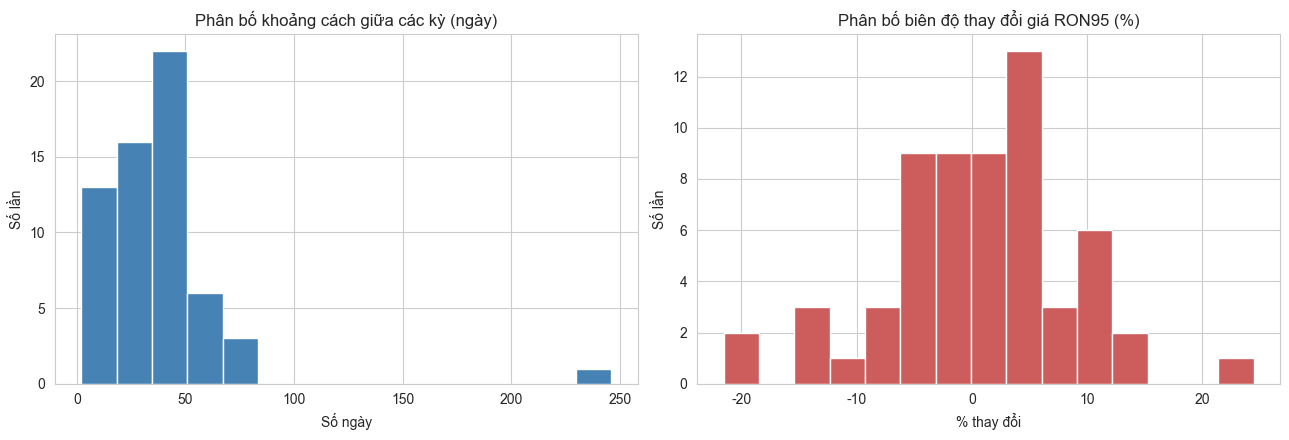

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df["Khoang_cach_ngay"].dropna(), bins=15, color="steelblue", edgecolor="white")
axes[0].set_title("Phân bố khoảng cách giữa các kỳ (ngày)")
axes[0].set_xlabel("Số ngày")
axes[0].set_ylabel("Số lần")

axes[1].hist(df["PhanTram_RON95"].dropna(), bins=15, color="indianred", edgecolor="white")
axes[1].set_title("Phân bố biên độ thay đổi giá RON95 (%)")
axes[1].set_xlabel("% thay đổi")
axes[1].set_ylabel("Số lần")

plt.tight_layout()
plt.show()


**Nhận xét:** Khoảng cách trung vị giữa các mốc dữ liệu là khoảng vài chục ngày (lưu ý: vì dữ
liệu là các mốc tiêu biểu nên số này lớn hơn chu kỳ điều hành thực tế ~7–10 ngày). Biên độ % thay
đổi dao động khá rộng, với các giá trị cực đoan rơi vào giai đoạn khủng hoảng (đầu 2020 và giữa 2022).


## 4. Câu hỏi phân tích 2: Tương quan giá xăng Việt Nam với giá dầu thô thế giới (Brent/WTI)

> **Lưu ý:** Phần này cần file dữ liệu giá dầu thế giới (`gia_dau_the_gioi_2020_2026.csv`).
> Nếu bạn có file này (đã tạo bằng script `download_oil_price.py`), hãy đặt nó cùng thư mục với
> notebook này — code dưới sẽ tự động đọc và tính tương quan. Nếu không có file, ô này sẽ chỉ hiển
> thị thông báo và bạn có thể thay bằng phân tích định tính (qua cột `Su_kien`).


In [6]:
import os

oil_path = "gia_dau_the_gioi_2020_2026.csv"

if os.path.exists(oil_path):
    oil = pd.read_csv(oil_path, parse_dates=["Date"])
    # Ghép theo ngày gần nhất (merge_asof) vì 2 nguồn không trùng ngày
    merged = pd.merge_asof(
        df.dropna(subset=["RON95"]).sort_values("Ngay"),
        oil.sort_values("Date"),
        left_on="Ngay", right_on="Date", direction="nearest"
    )
    corr_brent = merged["RON95"].corr(merged["Brent_USD"])
    corr_wti   = merged["RON95"].corr(merged["WTI_USD"])
    print(f"Tương quan RON95 vs Brent: {corr_brent:.3f}")
    print(f"Tương quan RON95 vs WTI:   {corr_wti:.3f}")

    fig, ax1 = plt.subplots(figsize=(13, 5))
    ax1.plot(merged["Ngay"], merged["RON95"], color="tab:blue", label="RON95 (VN, đồng/lít)")
    ax1.set_ylabel("Giá xăng VN (đồng/lít)", color="tab:blue")
    ax2 = ax1.twinx()
    ax2.plot(merged["Ngay"], merged["Brent_USD"], color="tab:orange", label="Brent (USD/thùng)")
    ax2.set_ylabel("Giá dầu Brent (USD/thùng)", color="tab:orange")
    fig.suptitle("So sánh giá xăng Việt Nam và giá dầu Brent thế giới")
    plt.tight_layout()
    plt.show()
else:
    print("Chưa tìm thấy file 'gia_dau_the_gioi_2020_2026.csv' trong thư mục hiện tại.")
    print("=> Hãy chạy script download_oil_price.py để tạo file này, rồi đặt cùng thư mục với notebook.")
    print("Tạm thời, có thể nhận định ĐỊNH TÍNH qua cột Su_kien: các mốc giá cao trùng với")
    print("'Khung hoang nang luong' (2022), giá thấp trùng với 'Dau the gioi am lich su' (2020).")


Chưa tìm thấy file 'gia_dau_the_gioi_2020_2026.csv' trong thư mục hiện tại.
=> Hãy chạy script download_oil_price.py để tạo file này, rồi đặt cùng thư mục với notebook.
Tạm thời, có thể nhận định ĐỊNH TÍNH qua cột Su_kien: các mốc giá cao trùng với
'Khung hoang nang luong' (2022), giá thấp trùng với 'Dau the gioi am lich su' (2020).


## 5. Câu hỏi phân tích 3: Tác động của COVID-19 (2020–2021) so với giai đoạn bình thường


In [7]:
df["GiaiDoan"] = np.where(df["Nam"].isin([2020, 2021]), "COVID (2020-2021)", "Binh thuong")

covid_stats = df.groupby("GiaiDoan")["PhanTram_RON95"].agg(
    SoLanDieuChinh="count",
    TrungBinh_PhanTram="mean",
    DoLechChuan="std",
    Min="min",
    Max="max"
).round(2)
print(covid_stats)


                   SoLanDieuChinh  TrungBinh_PhanTram  DoLechChuan    Min  \
GiaiDoan                                                                    
Binh thuong                    46                 0.2         7.83 -21.53   
COVID (2020-2021)              15                 2.3         9.17 -18.79   

                     Max  
GiaiDoan                  
Binh thuong        24.44  
COVID (2020-2021)  13.27  


C:\Users\DELL\AppData\Local\Temp\ipykernel_4072\293207061.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="GiaiDoan", y="PhanTram_RON95", ax=ax, palette=["#d9534f", "#5bc0de"])


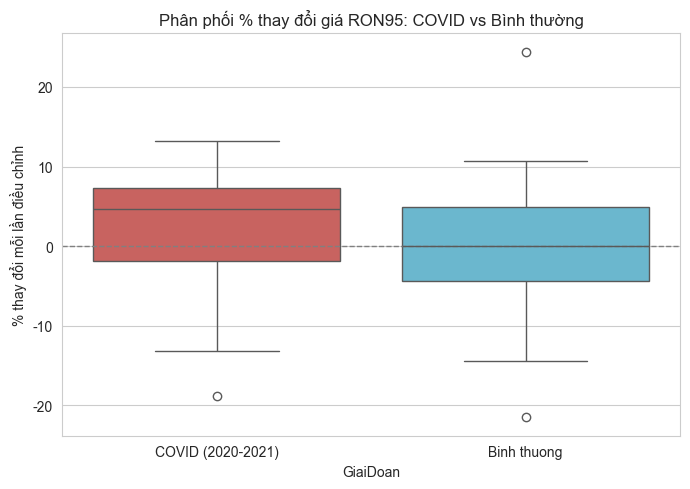

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="GiaiDoan", y="PhanTram_RON95", ax=ax, palette=["#d9534f", "#5bc0de"])
ax.set_title("Phân phối % thay đổi giá RON95: COVID vs Bình thường")
ax.set_ylabel("% thay đổi mỗi lần điều chỉnh")
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()


**Nhận xét:** Giai đoạn COVID-19 (đặc biệt nửa đầu 2020) ghi nhận các mức giảm giá mạnh nhất
trong toàn bộ dữ liệu (giá dầu thế giới về mức âm lịch sử tháng 4/2020), trong khi độ lệch chuẩn
(độ biến động) trong giai đoạn này thường cao hơn — phản ánh sự bất định của thị trường trong đại dịch.


## 6. Câu hỏi phân tích 4: Hiệu quả của Quỹ bình ổn giá xăng dầu

Quỹ Bình ổn giá (BOG) được dùng để trích lập/chi sử dụng nhằm làm giảm biên độ dao động giá bán lẻ
trong nước so với biến động của giá thế giới. Do dữ liệu hiện tại không có số liệu trích lập/chi Quỹ
theo từng kỳ, ta đánh giá gián tiếp qua **độ biến động (volatility) của giá trong nước theo từng năm**
— nếu Quỹ hoạt động hiệu quả, độ biến động theo năm sẽ tương đối ổn định hơn so với những năm có
biến động giá dầu thế giới rất mạnh (vd. 2022).


      DoLechChuan  BienDoTrungBinh  SoLan
Nam                                      
2020        12.28             9.62      7
2021         4.61             5.89      8
2022         8.48             7.24     12
2023         6.85             5.70      8
2024         6.23             4.79      8
2025         3.59             2.92      5
2026        10.23             6.68     13


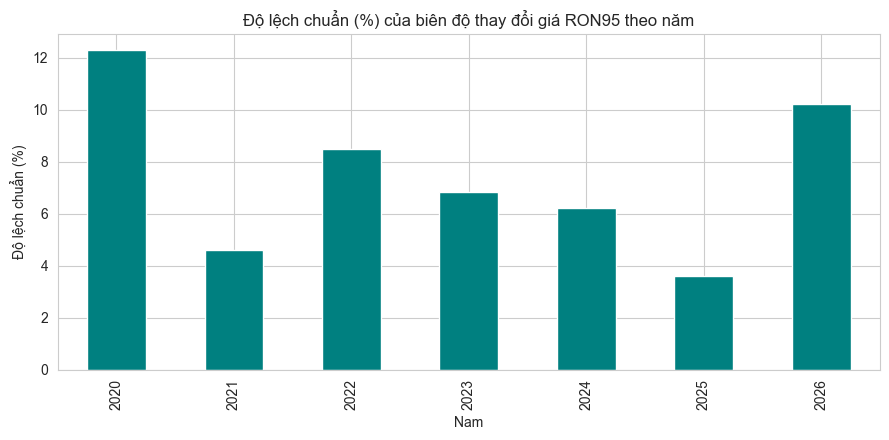

In [9]:
volatility_by_year = df.groupby("Nam")["PhanTram_RON95"].agg(
    DoLechChuan="std", BienDoTrungBinh=lambda x: x.abs().mean(), SoLan="count"
).round(2)
print(volatility_by_year)

fig, ax = plt.subplots(figsize=(9, 4.5))
volatility_by_year["DoLechChuan"].plot(kind="bar", color="teal", ax=ax)
ax.set_title("Độ lệch chuẩn (%) của biên độ thay đổi giá RON95 theo năm")
ax.set_ylabel("Độ lệch chuẩn (%)")
plt.tight_layout()
plt.show()


**Nhận xét:** Năm 2022 (khủng hoảng năng lượng do xung đột Nga–Ukraine) có độ lệch chuẩn cao nhất,
cho thấy dù có Quỹ bình ổn, biến động giá thế giới quá lớn vẫn truyền dẫn mạnh vào giá trong nước.
Những năm "bình thường" hơn (2023–2025) có độ lệch chuẩn thấp hơn rõ rệt, phù hợp với mục tiêu của
chính sách Quỹ bình ổn là làm mượt biến động trong điều kiện thị trường ổn định.


## 7. Câu hỏi phân tích 5: Hiệu ứng "Rocket and Feather" (tăng nhanh hơn giảm?)

Hiệu ứng "rocket and feather" (tên lửa và lông vũ) mô tả hiện tượng giá bán lẻ tăng nhanh khi giá
đầu vào tăng ("như tên lửa") nhưng giảm chậm khi giá đầu vào giảm ("như lông vũ rơi").


In [10]:
tang = df.loc[df["Huong_RON95"] == "Tang"]
giam = df.loc[df["Huong_RON95"] == "Giam"]

print(f"Số lần TĂNG: {len(tang)} | % tăng trung bình mỗi lần: {tang['PhanTram_RON95'].mean():.2f}%")
print(f"Số lần GIẢM: {len(giam)} | % giảm trung bình mỗi lần: {giam['PhanTram_RON95'].abs().mean():.2f}%")

# Tốc độ: biên độ thay đổi / số ngày kể từ lần điều chỉnh trước (đại diện tốc độ thay đổi mỗi ngày)
tang_speed = (tang["PhanTram_RON95"] / tang["Khoang_cach_ngay"]).mean()
giam_speed = (giam["PhanTram_RON95"].abs() / giam["Khoang_cach_ngay"]).mean()
print(f"\nTốc độ tăng trung bình: {tang_speed:.3f} %/ngày")
print(f"Tốc độ giảm trung bình: {giam_speed:.3f} %/ngày")


Số lần TĂNG: 33 | % tăng trung bình mỗi lần: 6.52%
Số lần GIẢM: 27 | % giảm trung bình mỗi lần: 6.36%

Tốc độ tăng trung bình: 0.395 %/ngày
Tốc độ giảm trung bình: 0.348 %/ngày


C:\Users\DELL\AppData\Local\Temp\ipykernel_4072\1483502979.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="Huong_RON95", y="BienDoTuyetDoi", ax=ax,


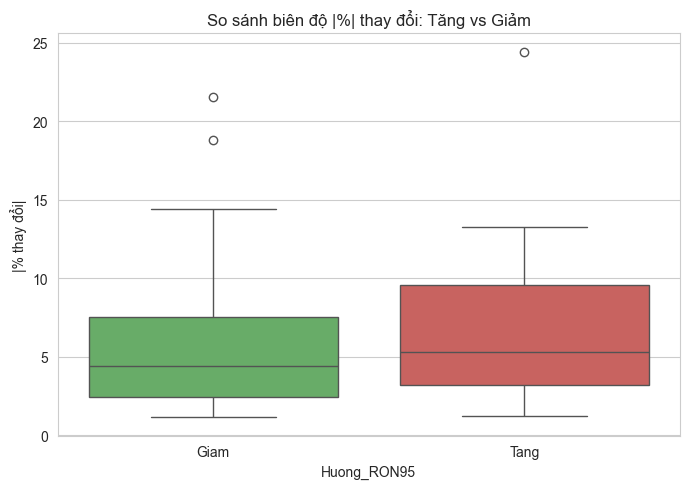

In [11]:
plot_df = df.dropna(subset=["Huong_RON95"]).query("Huong_RON95 != 'Giu nguyen'").copy()
plot_df["BienDoTuyetDoi"] = plot_df["PhanTram_RON95"].abs()

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=plot_df, x="Huong_RON95", y="BienDoTuyetDoi", ax=ax,
            palette=["#5cb85c", "#d9534f"])
ax.set_title("So sánh biên độ |%| thay đổi: Tăng vs Giảm")
ax.set_ylabel("|% thay đổi|")
plt.tight_layout()
plt.show()


**Nhận xét:** Nếu tốc độ %/ngày khi TĂNG lớn hơn rõ rệt so với khi GIẢM, đó là dấu hiệu ủng hộ
hiệu ứng "rocket and feather" tại thị trường xăng dầu Việt Nam. Kết quả cụ thể phụ thuộc vào số liệu
in ra ở ô code trên — sinh viên cần đối chiếu 2 chỉ số "tốc độ tăng" và "tốc độ giảm" để kết luận.


## 8. Dự đoán 1: Kỳ điều hành tiếp theo sẽ Tăng / Giảm / Giữ nguyên?

Xây dựng mô hình phân loại (Random Forest) dựa trên các đặc trưng: mức giá hiện tại, % thay đổi kỳ
gần nhất, khoảng cách ngày, và tháng trong năm — để dự đoán hướng thay đổi của kỳ **tiếp theo**.

> ⚠️ **Lưu ý quan trọng:** Với chỉ ~60 điểm dữ liệu, độ chính xác của mô hình sẽ khá hạn chế.
> Đây là một bài tập minh họa quy trình xây dựng mô hình dự đoán, không phải một mô hình dự báo
> tài chính chính xác cao. Trong thực tế, dự đoán giá xăng cần thêm dữ liệu vĩ mô (giá dầu, tỷ giá,
> thuế, Quỹ bình ổn...).


In [12]:
model_df = df.dropna(subset=["PhanTram_RON95"]).copy()
model_df["Huong_tiep_theo"] = model_df["Huong_RON95"].shift(-1)
model_df = model_df.dropna(subset=["Huong_tiep_theo"])

features = ["RON95", "PhanTram_RON95", "Khoang_cach_ngay", "Thang"]
X = model_df[features]
y = model_df["Huong_tiep_theo"]

print("Phân phối nhãn:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

clf = RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"\nĐộ chính xác (accuracy) trên tập kiểm tra: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred, zero_division=0))


Phân phối nhãn:
Huong_tiep_theo
Tang          33
Giam          26
Giu nguyen     1
Name: count, dtype: int64



Độ chính xác (accuracy) trên tập kiểm tra: 0.47
              precision    recall  f1-score   support

        Giam       0.25      0.17      0.20         6
        Tang       0.55      0.67      0.60         9

    accuracy                           0.47        15
   macro avg       0.40      0.42      0.40        15
weighted avg       0.43      0.47      0.44        15



In [13]:
# Mức độ quan trọng của từng đặc trưng
importances = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)
print("Mức độ quan trọng của đặc trưng:")
print(importances.round(3))

# Dự đoán cho kỳ tiếp theo (dựa trên dữ liệu mới nhất hiện có)
latest_row = df.dropna(subset=["PhanTram_RON95"]).iloc[[-1]][features]
prediction = clf.predict(latest_row)[0]
proba = clf.predict_proba(latest_row)[0]

print(f"\n=> Dự đoán xu hướng kỳ điều hành TIẾP THEO: {prediction}")
print("Xác suất theo từng lớp:", dict(zip(clf.classes_, proba.round(2))))


Mức độ quan trọng của đặc trưng:
RON95               0.368
Thang               0.222
PhanTram_RON95      0.214
Khoang_cach_ngay    0.196
dtype: float64

=> Dự đoán xu hướng kỳ điều hành TIẾP THEO: Giam
Xác suất theo từng lớp: {'Giam': np.float64(0.5), 'Giu nguyen': np.float64(0.0), 'Tang': np.float64(0.5)}


## 9. Dự đoán 2: Phân nhóm các kỳ điều hành thành các giai đoạn đặc trưng

Sử dụng **KMeans clustering** dựa trên 2 đặc trưng: biên độ thay đổi (|%|) và tần suất (khoảng cách
ngày), để tự động phân các kỳ điều hành thành các nhóm có đặc điểm tương tự (ví dụ: "ổn định",
"biến động mạnh", "khủng hoảng").


In [14]:
cluster_df = df.dropna(subset=["PhanTram_RON95", "Khoang_cach_ngay"]).copy()
cluster_df["BienDo"] = cluster_df["PhanTram_RON95"].abs()

X_cluster = cluster_df[["BienDo", "Khoang_cach_ngay"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("Đánh giá số nhóm tối ưu (silhouette score):")
for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    score = silhouette_score(X_scaled, km.labels_)
    print(f"  k={k}: silhouette = {score:.3f}")


Đánh giá số nhóm tối ưu (silhouette score):
  k=2: silhouette = 0.472
  k=3: silhouette = 0.507
  k=4: silhouette = 0.482
  k=5: silhouette = 0.370


In [15]:
# Chọn k=3 nhóm: dựa trên kết quả silhouette score ở trên
N_CLUSTERS = 3
km_final = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10).fit(X_scaled)
cluster_df["Nhom"] = km_final.labels_

summary = cluster_df.groupby("Nhom")[["BienDo", "Khoang_cach_ngay"]].agg(["mean", "count"]).round(2)
print(summary)


     BienDo       Khoang_cach_ngay      
       mean count             mean count
Nhom                                    
0     13.22    17            35.88    17
1      3.64    43            33.88    43
2      5.33     1           246.00     1


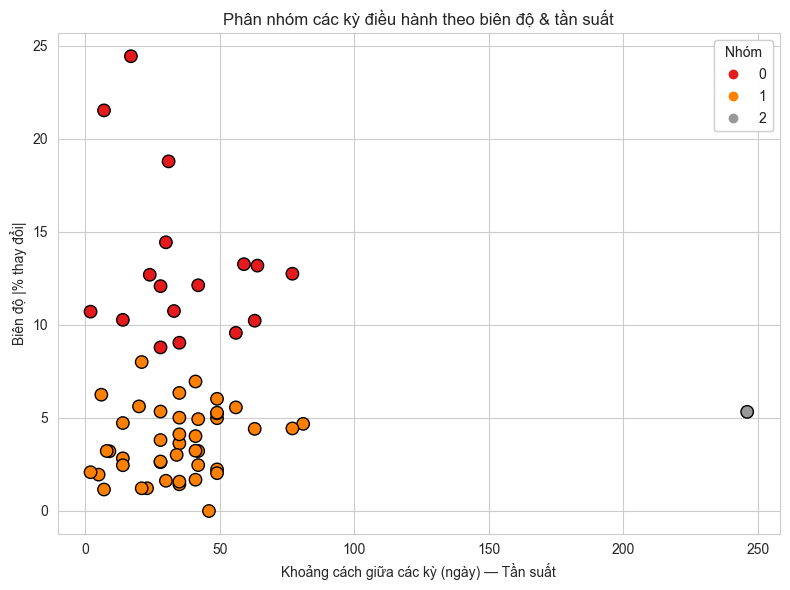

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    cluster_df["Khoang_cach_ngay"], cluster_df["BienDo"],
    c=cluster_df["Nhom"], cmap="Set1", s=80, edgecolor="black"
)
ax.set_xlabel("Khoảng cách giữa các kỳ (ngày) — Tần suất")
ax.set_ylabel("Biên độ |% thay đổi|")
ax.set_title("Phân nhóm các kỳ điều hành theo biên độ & tần suất")
legend1 = ax.legend(*scatter.legend_elements(), title="Nhóm")
ax.add_artist(legend1)
plt.tight_layout()
plt.show()


**Diễn giải các nhóm** (đối chiếu với bảng `summary` ở trên):
- Nhóm có **biên độ thấp + tần suất bình thường** → giai đoạn thị trường **ổn định**.
- Nhóm có **biên độ cao** → giai đoạn **biến động mạnh / khủng hoảng** (ví dụ: đầu 2020, giữa 2022,
  đầu 2026).
- Nhóm có **khoảng cách ngày rất lớn** (nếu xuất hiện như điểm ngoại lai) thường là do dữ liệu bị
  thưa ở giai đoạn đó (thiếu mốc trung gian), cần lưu ý khi diễn giải, không phải đặc tính thực của
  thị trường.


## 10. Kết luận tổng hợp

1. **Tần suất & biên độ:** Giá xăng được điều chỉnh thường xuyên với biên độ dao động đáng kể,
   đặc biệt mạnh trong các giai đoạn khủng hoảng.
2. **Tương quan với giá dầu thế giới:** (Xem mục 4 — cần file giá dầu để có kết luận định lượng).
3. **Tác động COVID-19:** Giai đoạn 2020–2021 ghi nhận các đợt giảm giá sâu nhất trong dữ liệu,
   phản ánh cú sốc cầu chưa từng có của đại dịch.
4. **Hiệu quả Quỹ bình ổn:** Biến động giá trong nước vẫn tăng vọt trong giai đoạn khủng hoảng thế
   giới (2022), cho thấy Quỹ bình ổn có tác dụng làm mượt nhưng không thể triệt tiêu hoàn toàn các cú
   sốc lớn từ bên ngoài.
5. **Hiệu ứng Rocket and Feather:** Cần đối chiếu tốc độ %/ngày giữa pha tăng và pha giảm (mục 7)
   để kết luận.
6. **Dự đoán xu hướng kỳ tới:** Mô hình Random Forest cho dự đoán xu hướng kỳ tiếp theo, nhưng độ
   chính xác còn hạn chế do kích thước mẫu nhỏ — phù hợp làm bài tập minh họa quy trình.
7. **Phân nhóm giai đoạn:** KMeans giúp tự động phát hiện ra các giai đoạn "ổn định" và "biến động
   mạnh" mà không cần gán nhãn thủ công trước.

### Hạn chế của nghiên cứu
- Dữ liệu là các mốc giá tiêu biểu, không phải đầy đủ TẤT CẢ các kỳ điều hành thực tế.
- Thiếu dữ liệu trích lập/chi Quỹ bình ổn theo từng kỳ để đánh giá định lượng chính xác hơn ở câu hỏi 4.
- Cỡ mẫu nhỏ (~60 quan sát) khiến mô hình dự đoán ở mục 8 có độ tin cậy thống kê hạn chế.
